# Router2 Summary Visualization

Use this notebook to inspect the Router2 and RouterDC results saved in this folder.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

## Load Results

In [2]:
ROOT = Path.cwd().resolve()
if (ROOT / "router2_summary.csv").exists():
    SUMMARY_DIR = ROOT
elif (ROOT / "results" / "router2_summary" / "router2_summary.csv").exists():
    SUMMARY_DIR = ROOT / "results" / "router2_summary"
elif (ROOT.parent / "results" / "router2_summary" / "router2_summary.csv").exists():
    SUMMARY_DIR = ROOT.parent / "results" / "router2_summary"
else:
    raise FileNotFoundError("Could not find results/router2_summary/router2_summary.csv")

summary_path = SUMMARY_DIR / "router2_summary.csv"
results_df = pd.read_csv(summary_path)

for column in ("test_mae", "test_mse", "test_rmse"):
    results_df[column] = pd.to_numeric(results_df[column], errors="coerce")

print(f"Loaded {len(results_df)} rows from {summary_path}")

Loaded 26 rows from C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\router2_summary\router2_summary.csv


## All Results

In [3]:
all_results_view = (
    results_df[
        [
            "router_variant",
            "method",
            "result_type",
            "test_mae",
            "test_mse",
            "test_rmse",
        ]
    ]
    .sort_values(["router_variant", "test_mae"])
    .round(6)
)

display(all_results_view)

,router_variant,method,result_type,test_mae,test_mse,test_rmse
9,multiscale_tcn_expert_embeddings,Fixed validation-based soft weights,baseline,0.339299,0.310752,0.557452
10,multiscale_tcn_expert_embeddings,Fixed equal average,baseline,0.339679,0.311100,0.557763
11,multiscale_tcn_expert_embeddings,Multiscale TCN expert-embedding router,trained_router,0.340580,0.312310,0.558847
12,multiscale_tcn_expert_embeddings,DLinear,single_expert_baseline,0.347946,0.331420,0.575691
13,multiscale_tcn_expert_embeddings,ModernTCN,single_expert_baseline,0.351190,0.322122,0.567558
14,multiscale_tcn_expert_embeddings,Validation-selected best expert,baseline,0.351190,0.322122,0.567558
15,multiscale_tcn_expert_embeddings,PatchTST,single_expert_baseline,0.363932,0.336096,0.579738
16,multiscale_tcn_expert_embeddings,TimesNet,single_expert_baseline,0.366520,0.352346,0.593587
17,multiscale_tcn_expert_embeddings,iTransformer,single_expert_baseline,0.400857,0.375448,0.612738
0,original,Fixed validation-based soft weights,baseline,0.339299,0.310752,0.557452


## Best Row Per Router Variant

In [4]:
best_by_variant_df = (
    results_df.sort_values(["router_variant", "test_mae"])
    .groupby("router_variant", as_index=False)
    .first()
    .sort_values("test_mae")
)

display(
    best_by_variant_df[
        ["router_variant", "method", "result_type", "test_mae"]
    ].round(6)
)

,router_variant,method,result_type,test_mae
2,routerdc_hard,Oracle best expert per window,oracle,0.308871
0,multiscale_tcn_expert_embeddings,Fixed validation-based soft weights,baseline,0.339299
1,original,Fixed validation-based soft weights,baseline,0.339299


## Trained Routers Only

In [5]:
trained_router_df = (
    results_df[results_df["result_type"].eq("trained_router")]
    .copy()
    .sort_values("test_mae")
)

display(
    trained_router_df[
        ["router_variant", "method", "test_mae", "test_mse", "test_rmse"]
    ].round(6)
)

,router_variant,method,test_mae,test_mse,test_rmse
1,original,Router 2 feature router,0.339421,0.314064,0.560414
11,multiscale_tcn_expert_embeddings,Multiscale TCN expert-embedding router,0.340580,0.312310,0.558847
21,routerdc_hard,RouterDC hard (without_contrastive),0.351879,NaN,NaN
24,routerdc_hard,RouterDC hard (with_contrastive),0.388759,NaN,NaN


## Chart: Best MAE Per Variant

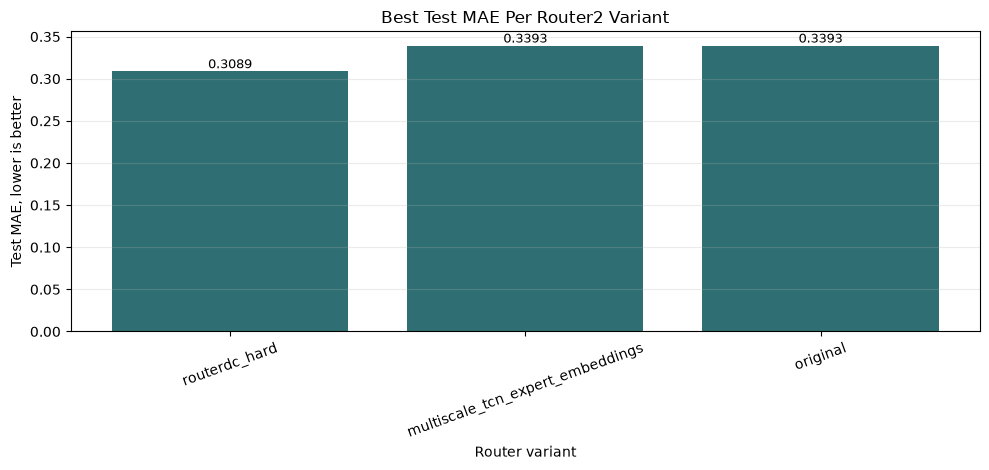

Saved C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\router2_summary\router2_best_mae_by_variant.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(
    best_by_variant_df["router_variant"],
    best_by_variant_df["test_mae"],
    color="#2f6f73",
)

ax.set_title("Best Test MAE Per Router2 Variant")
ax.set_xlabel("Router variant")
ax.set_ylabel("Test MAE, lower is better")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=20)

for bar, value in zip(bars, best_by_variant_df["test_mae"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
chart_path = SUMMARY_DIR / "router2_best_mae_by_variant.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {chart_path}")

## Chart: Trained Routers

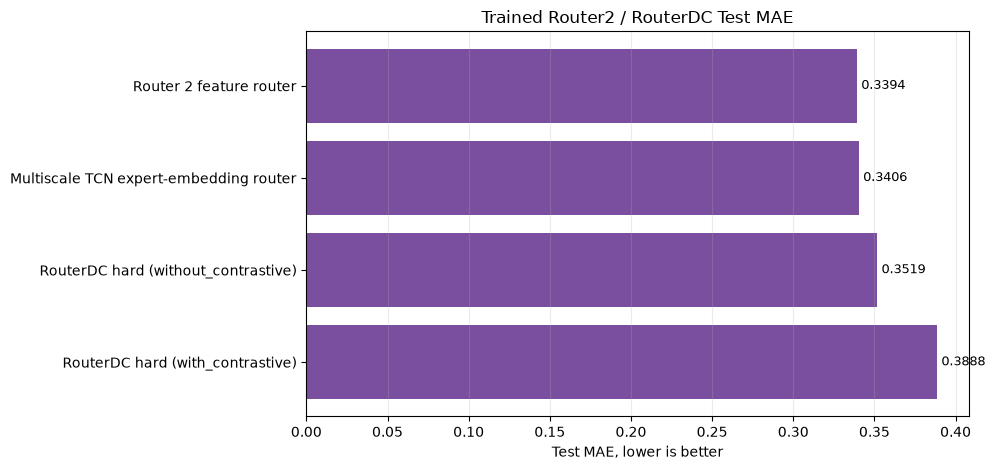

Saved C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\router2_summary\router2_trained_routers_mae.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.barh(
    trained_router_df["method"],
    trained_router_df["test_mae"],
    color="#7a4f9f",
)

ax.set_title("Trained Router2 / RouterDC Test MAE")
ax.set_xlabel("Test MAE, lower is better")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

for bar, value in zip(bars, trained_router_df["test_mae"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
chart_path = SUMMARY_DIR / "router2_trained_routers_mae.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {chart_path}")

## Chart: Soft Router2 Vs Baselines

method,Fixed validation-based soft weights,Fixed equal average,Router 2 feature router,Multiscale TCN expert-embedding router
router_variant,,,,
multiscale_tcn_expert_embeddings,0.339299,0.339679,NaN,0.34058
original,0.339299,0.339679,0.339421,NaN


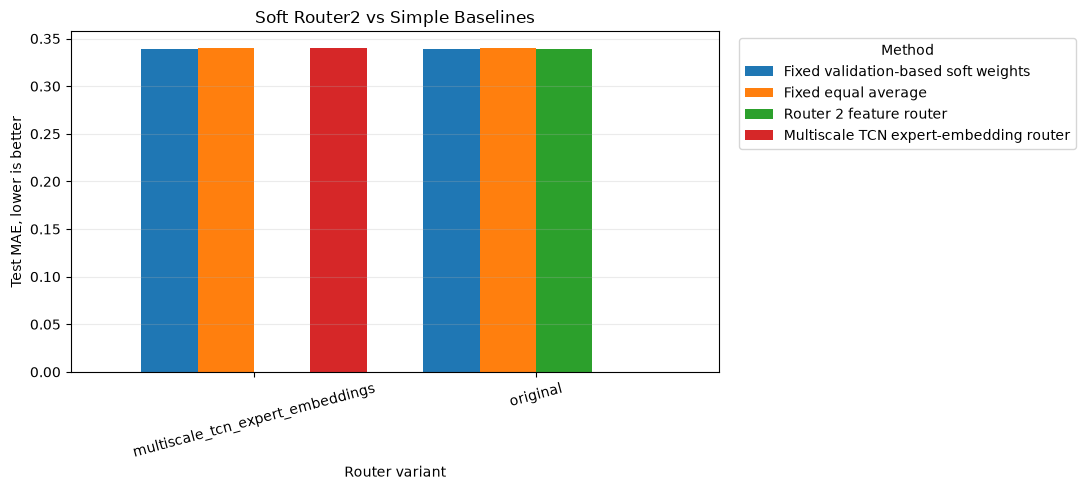

Saved C:\Users\luwil\OneDrive\Documents\Code\BasicTS\results\router2_summary\router2_soft_vs_baselines.png


In [8]:
soft_methods = [
    "Fixed validation-based soft weights",
    "Fixed equal average",
    "Router 2 feature router",
    "Multiscale TCN expert-embedding router",
]

soft_df = results_df[
    results_df["router_family"].eq("soft_router2")
    & results_df["method"].isin(soft_methods)
]

pivot_df = soft_df.pivot_table(
    index="router_variant",
    columns="method",
    values="test_mae",
    aggfunc="first",
)
pivot_df = pivot_df[[method for method in soft_methods if method in pivot_df.columns]]

display(pivot_df.round(6))

ax = pivot_df.plot(kind="bar", figsize=(11, 5), width=0.8)
ax.set_title("Soft Router2 vs Simple Baselines")
ax.set_xlabel("Router variant")
ax.set_ylabel("Test MAE, lower is better")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
chart_path = SUMMARY_DIR / "router2_soft_vs_baselines.png"
plt.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {chart_path}")

## Files In This Folder

In [9]:
for path in sorted(SUMMARY_DIR.iterdir()):
    if path.is_file():
        print(path.name)

router2_best_mae_by_variant.png
router2_multiscale_tcn_expert_embeddings_test_comparison.csv
router2_multiscale_tcn_expert_embeddings_test_metrics.json
router2_soft_vs_baselines.png
router2_summary.csv
router2_summary_visualization.ipynb
router2_test_comparison.csv
router2_test_metrics.json
router2_trained_routers_mae.png
routerdc_hard_test_comparison.csv
routerdc_hard_test_metrics.json
visualize_router2_summary.py
